In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
DATA_PATH = "../datasets/Messy_Employee_dataset.csv"
TARGET = "Salary"
RANDOM_STATE = 13
TEST_SIZE = 0.2

CATEGORICAL_FEATURES = ["Status", "Department", "Region"]
NUMERIC_FEATURES = ["Age", "Experience", "Remote_Work", "Performance_Score"]

In [3]:
data = pd.read_csv(DATA_PATH)

print(data.shape)
display(data.head())
data.info()
data.isna().sum()

(1020, 12)


,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   str    
 1   First_Name         1020 non-null   str    
 2   Last_Name          1020 non-null   str    
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   str    
 5   Status             1020 non-null   str    
 6   Join_Date          1020 non-null   str    
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   str    
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   str    
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), str(8)
memory usage: 88.8 KB


Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64

In [4]:
# drop rows with missing target
data = data.dropna(subset=[TARGET]).copy()

# split columns to 2 different
data[["Department", "Region"]] = data["Department_Region"].str.split("-", expand=True)

# parse join date
data["Join_Date"] = pd.to_datetime(
    data["Join_Date"], format="%m/%d/%Y", errors="coerce"
)

# fixed reference date for reproducibility
reference_date = data["Join_Date"].max()

# create experience in years
data["Experience"] = ((reference_date - data["Join_Date"]).dt.days / 365.25).round(1)

# # ordinal encoding for performance
data["Performance_Score"] = (
    data["Performance_Score"]
    .str.strip()
    .map(
        {
            "Poor": 1,
            "Average": 2,
            "Good": 3,
            "Excellent": 4,
        }
    )
)

# make remote_work numeric
data["Remote_Work"] = data["Remote_Work"].map(
    {"TRUE": 1, "FALSE": 0, True: 1, False: 0}
)

# drop unused columns
data = data.drop(
    columns=[
        "Employee_ID",
        "First_Name",
        "Last_Name",
        "Email",
        "Phone",
        "Department_Region",
        "Join_Date",
    ]
)

data.head()

,Age,Status,Salary,Performance_Score,Remote_Work,Department,Region,Experience
0,25.0,Active,59767.65,2,1,DevOps,California,3.7
1,NaN,Active,65304.66,4,1,Finance,Texas,4.5
2,NaN,Pending,88145.90,3,1,Admin,Nevada,1.1
3,25.0,Inactive,69450.99,3,1,Admin,Nevada,3.1
4,25.0,Active,109324.61,1,0,Cloud Tech,Florida,3.0


In [5]:
X = data.drop(columns=TARGET)
y = data[TARGET]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [7]:
numeric_pipeline = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ]
)

In [8]:
model = Pipeline([("preprocessor", preprocessor), ("regressor", LinearRegression())])

In [9]:
model.fit(X_train, y_train)
None

In [10]:
y_pred = model.predict(X_test)

In [11]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"{mse=}")
print(f"{mae=}")
print(f"{r2=}")

mse=382450941.9619833
mae=16731.633536986177
r2=-0.03299936963600514


Metrics are really bad. R2 < 0 means that it predicts even worse than just mean salary

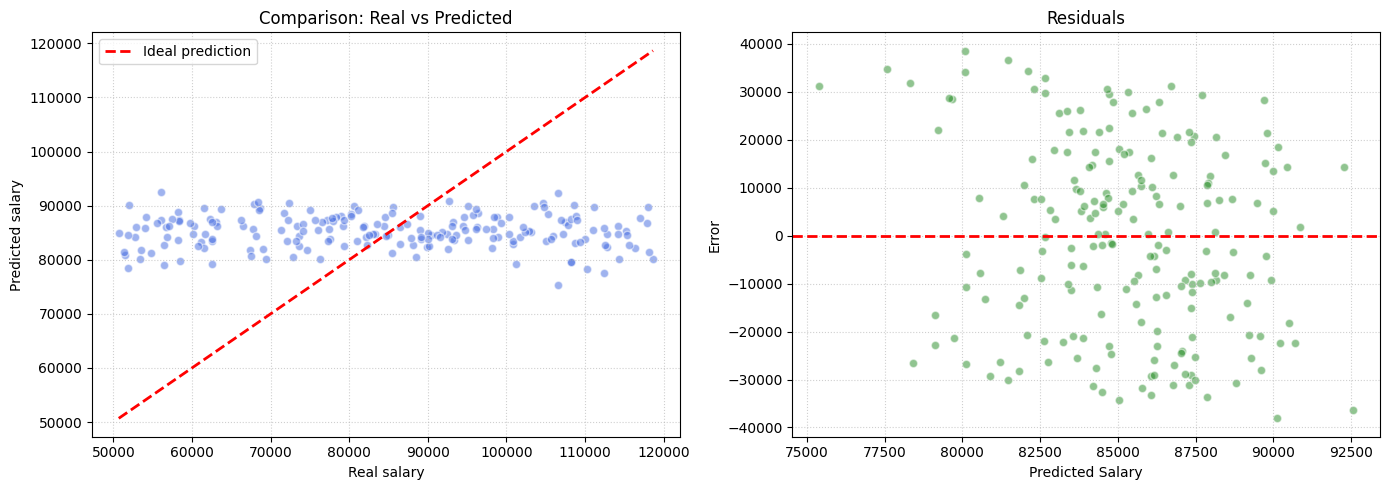

In [12]:
def plot_manual_regression(y_test, y_pred):
    residuals = y_test - y_pred
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Actual vs Predicted
    ax1.scatter(y_test, y_pred, color="royalblue", alpha=0.5, edgecolors="white")

    max_val = max(max(y_test), max(y_pred))
    min_val = min(min(y_test), min(y_pred))
    ax1.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="red",
        linestyle="--",
        lw=2,
        label="Ideal prediction",
    )

    ax1.set_title("Comparison: Real vs Predicted", fontsize=12)
    ax1.set_xlabel("Real salary")
    ax1.set_ylabel("Predicted salary")
    ax1.grid(True, linestyle=":", alpha=0.6)
    ax1.legend()

    # Residual Plot
    ax2.scatter(y_pred, residuals, color="forestgreen", alpha=0.5, edgecolors="white")
    ax2.axhline(y=0, color="red", linestyle="--", lw=2)

    ax2.set_title("Residuals", fontsize=12)
    ax2.set_xlabel("Predicted Salary")
    ax2.set_ylabel("Error")
    ax2.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_manual_regression(y_test, y_pred)

The graph here is very revealing.
The model predicts the same salary for almost all rows, somewhere in the range of 82k–89k.
The model does not see a useful signal in the features, so it slides to a forecast close to the average target value

In [13]:
for col in ["Status", "Department", "Region", "Remote_Work", "Performance_Score"]:
    print(f"\n--- {col} ---")
    print(
        data.groupby(col)["Salary"]
        .agg(["mean", "median", "std", "count"])
        .sort_values("mean")
    )


--- Status ---
                  mean     median           std  count
Status                                                
Inactive  84501.909733  83945.615  20078.176566    300
Active    85129.264752  85233.550  19473.606304    343
Pending   85735.199547  86653.960  20121.273065    353

--- Department ---
                    mean     median           std  count
Department                                              
Finance     82240.610417  83516.345  20197.718486    168
Cloud Tech  84923.036241  86618.370  19686.273190    141
Admin       85191.922795  87358.270  20036.817496    161
HR          85473.643174  85518.880  21054.964959    167
DevOps      86016.023641  85837.980  19265.237629    184
Sales       86896.681029  86850.370  18988.982416    175

--- Region ---
                    mean     median           std  count
Region                                                  
Nevada      83605.986747  82393.555  20785.374788    166
New York    83762.648291  82684.360  20444.397

Salary does not differ much for different groups.